In [725]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Data Import & Exploration / Datenimport & Exploration / Importation & Exploration des Données

FR : Le jeu de données provient de la plateforme Open Power System Data (OPSD), qui fournit des données énergétiques à l'échelle européenne. Il contient des séries temporelles horaires sur la consommation (charge) et la production d'énergies renouvelables.

EN : The dataset is sourced from the Open Power System Data (OPSD) platform, providing European-wide energy data. It contains hourly time series for load (consumption) and renewable energy generation.

DE : Der Datensatz stammt von der Plattform Open Power System Data (OPSD), die europaweite Energiedaten bereitstellt. Er enthält stündliche Zeitreihen zur Last (Verbrauch) und zur Erzeugung erneuerbarer Energien.

In [726]:
df = pd.read_csv(r'Data\timeseries60min.csv', parse_dates=['utc_timestamp'],
                 index_col=['utc_timestamp'])
df.head()
df.describe()
print(df.shape)
df.info()

(50401, 299)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50401 entries, 2014-12-31 23:00:00+00:00 to 2020-09-30 23:00:00+00:00
Columns: 299 entries, cet_cest_timestamp to UA_load_forecast_entsoe_transparency
dtypes: float64(298), object(1)
memory usage: 115.4+ MB


FR : Nous filtrons le tableau pour ne conserver que les colonnes relatives à l'Allemagne. Toutes les données concernant les autres pays européens sont supprimées pour isoler notre zone d'étude.

EN : We filter the table to keep only the columns related to Germany. All data regarding other European countries is removed to isolate our study area.

DE : Wir filtern die Tabelle, um nur die Spalten mit Bezug zu Deutschland zu behalten. Alle Daten zu anderen europäischen Ländern werden entfernt, um unser Untersuchungsgebiet zu isolieren.

In [727]:
Deutsch_columns = [col for col in df.columns if col.startswith('DE_')]
df_Deutschland = df[Deutsch_columns].copy()
df_Deutschland.head()
print(df_Deutschland.shape)



(50401, 41)


FR : Nous affinons le filtrage en supprimant les colonnes d'interconnexion. Ces colonnes représentent les échanges énergétiques entre l'Allemagne et ses voisins (ex: DE_AT, DE_LU). Nous ne conservons que les données de production et de consommation propres au territoire national.

EN : We refine the filtering by removing interconnection columns. These columns represent energy exchanges between Germany and its neighbors (e.g., DE_AT, DE_LU). We only keep production and consumption data specific to the national territory.

DE : Wir verfeinern die Filterung, indem wir die Interkonnektionsspalten entfernen. Diese Spalten stellen den Energieaustausch zwischen Deutschland und seinen Nachbarn dar (z. B. DE_AT, DE_LU). Wir behalten nur die produktions- und verbrauchsbezogenen Daten für das Staatsgebiet.

In [728]:

#df_Deutschland.dropna(axis='index', how='all')
#print (df_Deutschland.shape)
#df_Deutschland.isnull().head()
#df_Deutschland.count()
df_columnswithoutLU = [col for col in df_Deutschland if '_LU_'not in col]
df_Deutschland = df_Deutschland[df_columnswithoutLU].copy()
#df_Deutschland.count()
#df_Deutschland.info()
df_Deutschland.shape
#df_Deutschland.head()







(50401, 34)

FR :  Traitement des valeurs manquantes et Filtrage des lignes
Nous analysons la présence de données nulles (NaN), particulièrement pour le profil solaire. Nous choisissons de supprimer les lignes où la consommation réelle (DE_load_actual) est manquante, car cette variable est indispensable à notre analyse comparative.

EN :  Handling Missing Values and Row Filtering
We analyze the presence of null data (NaN), specifically for the solar profile. We choose to drop rows where the actual load (DE_load_actual) is missing, as this variable is essential for our comparative analysis.

DE :  Umgang mit fehlenden Werten und Zeilenfilterung
Wir analysieren das Vorhandensein von Nullwerten (NaN), insbesondere für das Solarprofil. Wir entscheiden uns, Zeilen zu löschen, in denen die tatsächliche Last (DE_load_actual) fehlt, da diese Variable für unsere vergleichende Analyse unerlässlich ist.

In [729]:
df_Deutschland['DE_solar_profile'].isna()
print(df_Deutschland.iloc[0])
df_Deutschland = df_Deutschland.dropna(subset=['DE_load_actual_entsoe_transparency'])
df_Deutschland.head()


DE_load_actual_entsoe_transparency                     NaN
DE_load_forecast_entsoe_transparency                   NaN
DE_solar_capacity                                  37248.0
DE_solar_generation_actual                             NaN
DE_solar_profile                                       NaN
DE_wind_capacity                                   27913.0
DE_wind_generation_actual                              NaN
DE_wind_profile                                        NaN
DE_wind_offshore_capacity                            667.0
DE_wind_offshore_generation_actual                     NaN
DE_wind_offshore_profile                               NaN
DE_wind_onshore_capacity                           27246.0
DE_wind_onshore_generation_actual                      NaN
DE_wind_onshore_profile                                NaN
DE_50hertz_load_actual_entsoe_transparency             NaN
DE_50hertz_load_forecast_entsoe_transparency           NaN
DE_50hertz_solar_generation_actual                     N

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,517.0,...,13841.0,13362.0,NaN,3866.0,469.0,3398.0,5307.0,4703.0,NaN,5.0
2015-01-01 01:00:00+00:00,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,514.0,...,13267.0,12858.0,NaN,3974.0,466.0,3508.0,5087.0,4562.0,NaN,7.0
2015-01-01 02:00:00+00:00,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,667.0,518.0,...,12702.0,12611.0,NaN,4194.0,470.0,3724.0,4906.0,4517.0,NaN,8.0
2015-01-01 03:00:00+00:00,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,667.0,520.0,...,12452.0,12490.0,NaN,4446.0,473.0,3973.0,4865.0,4601.0,NaN,11.0
2015-01-01 04:00:00+00:00,38941.0,38773.0,37248.0,NaN,NaN,27913.0,9231.0,0.3307,667.0,520.0,...,12454.0,12464.0,NaN,4671.0,474.0,4198.0,4685.0,4519.0,NaN,6.0


FR : Exclusion des données par gestionnaire de réseau (TSO)
Nous filtrons le dataset pour supprimer les colonnes spécifiques aux quatre grands gestionnaires de réseau allemands (50Hertz, TenneT, Amprion, TransnetBW). Cette étape permet de ne conserver que les agrégats nationaux et d'éviter les redondances dans l'analyse.

EN :  Exclusion of Transmission System Operator (TSO) Data
We filter the dataset to remove columns specific to the four major German grid operators (50Hertz, TenneT, Amprion, TransnetBW). This step ensures that only national aggregates are kept, avoiding redundancies in the analysis.

DE :  Ausschluss der Übertragungsnetzbetreiber-Daten (ÜNB)
Wir filtern den Datensatz, um die spezifischen Spalten der vier großen deutschen Übertragungsnetzbetreiber (50Hertz, TenneT, Amprion, TransnetBW) zu entfernen. Dieser Schritt dient dazu, nur die nationalen Aggregate zu behalten und Redundanzen in der Analyse zu vermeiden.


In [730]:

company_name = ['50hertz', 'tennet', 'amprion', 'transnetbw']
KeepColumns = [col for col in df_Deutschland.columns 
               if not any(name in col.lower() for name in company_name)]
df_Deutschland = df_Deutschland[KeepColumns].copy()
print(df_Deutschland.columns.tolist())
df_Deutschland.shape
df_Deutschland.describe()


['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile']


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
count,50400.000000,50376.000000,43799.000000,50297.000000,43696.000000,43799.000000,50326.000000,43725.000000,43799.000000,50326.000000,43725.000000,43799.000000,50328.000000,43727.000000
mean,55492.468552,54791.384231,42378.132240,4566.042905,0.101902,39972.882098,11552.234650,0.278908,3261.083312,1970.480984,0.570559,36711.810840,9581.469321,0.254253
std,10015.431042,9496.890313,4306.371168,6940.267590,0.155718,7262.640092,9076.350769,0.211566,1359.147670,1567.541202,0.393074,5961.336813,7987.848026,0.206999
min,31307.000000,28824.000000,37248.000000,0.000000,0.000000,27913.000000,135.000000,0.003800,667.000000,0.000000,0.000000,27246.000000,119.000000,0.004100
25%,47106.000000,46987.000000,38810.000000,0.000000,0.000000,33737.000000,4506.000000,0.114900,2219.000000,586.000000,0.207000,31519.000000,3534.000000,0.097400
50%,55092.000000,54731.500000,40941.000000,173.000000,0.003000,39808.000000,9015.000000,0.221100,3115.000000,1640.000000,0.538800,36693.000000,7128.500000,0.192000
75%,64309.250000,62877.250000,46092.000000,7342.000000,0.162300,47730.000000,16113.750000,0.389300,4486.000000,3066.000000,0.899300,43243.000000,13302.250000,0.351700
max,77549.000000,75912.000000,50508.000000,32947.000000,0.687300,50452.000000,46064.000000,1.078000,5742.000000,6901.000000,1.497900,44710.000000,40752.000000,1.088300


FR :  Analyse de la complétude des données de capacité
Nous identifions précisément la dernière occurrence de données valides pour la capacité solaire. Cette étape permet de confirmer jusqu'à quelle date les métadonnées techniques sont disponibles avant de procéder à une éventuelle extrapolation ou un remplissage des valeurs manquantes.

EN :  Capacity Data Completeness Analysis
We precisely identify the last occurrence of valid data for solar capacity. This step confirms up to which date technical metadata is available before proceeding with any potential extrapolation or filling of missing values.

DE :  Analyse der Vollständigkeit der Kapazitätsdaten
Wir identifizieren präzise das letzte Vorkommen gültiger Daten für die Solarkapazität. Dieser Schritt bestätigt, bis zu welchem Datum technische Metadaten verfügbar sind, bevor eine mögliche Extrapolation oder das Auffüllen fehlender Werte erfolgt.

In [731]:


index_valid = df_Deutschland['DE_solar_capacity'].last_valid_index()
valeur_final = df_Deutschland.loc[index_valid, 'DE_solar_capacity']
print (f"valeur trouve le {index_valid} : {valeur_final}")
LastDateCapa = df_Deutschland.dropna(subset = ['DE_solar_capacity'])
Truedate = LastDateCapa.index[-1]
print(f"{Truedate}")
df_Deutschland.describe()




valeur trouve le 2019-12-30 22:00:00+00:00 : 50508.0
2019-12-30 22:00:00+00:00


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
count,50400.000000,50376.000000,43799.000000,50297.000000,43696.000000,43799.000000,50326.000000,43725.000000,43799.000000,50326.000000,43725.000000,43799.000000,50328.000000,43727.000000
mean,55492.468552,54791.384231,42378.132240,4566.042905,0.101902,39972.882098,11552.234650,0.278908,3261.083312,1970.480984,0.570559,36711.810840,9581.469321,0.254253
std,10015.431042,9496.890313,4306.371168,6940.267590,0.155718,7262.640092,9076.350769,0.211566,1359.147670,1567.541202,0.393074,5961.336813,7987.848026,0.206999
min,31307.000000,28824.000000,37248.000000,0.000000,0.000000,27913.000000,135.000000,0.003800,667.000000,0.000000,0.000000,27246.000000,119.000000,0.004100
25%,47106.000000,46987.000000,38810.000000,0.000000,0.000000,33737.000000,4506.000000,0.114900,2219.000000,586.000000,0.207000,31519.000000,3534.000000,0.097400
50%,55092.000000,54731.500000,40941.000000,173.000000,0.003000,39808.000000,9015.000000,0.221100,3115.000000,1640.000000,0.538800,36693.000000,7128.500000,0.192000
75%,64309.250000,62877.250000,46092.000000,7342.000000,0.162300,47730.000000,16113.750000,0.389300,4486.000000,3066.000000,0.899300,43243.000000,13302.250000,0.351700
max,77549.000000,75912.000000,50508.000000,32947.000000,0.687300,50452.000000,46064.000000,1.078000,5742.000000,6901.000000,1.497900,44710.000000,40752.000000,1.088300


FR :  Imputation des données de capacité (Forward Fill)
Les données de capacité solaire sont structurellement croissantes et mises à jour moins fréquemment que la production. Après le 30/12/2019 à 22h, les données sont manquantes. Nous avons décidé de remplir ces vides en prolongeant la dernière valeur connue (50 508.02 MW), car la capacité installée ne peut pas régresser d'un jour à l'autre.

EN :  Capacity Data Imputation (Forward Fill)
Solar capacity data is structurally increasing and updated less frequently than production. After 12/30/2019 at 10 PM, data is missing. We decided to fill these gaps by extending the last known value (50,508.02 MW), as installed capacity cannot decrease from one day to the next.

DE :  Imputation der Kapazitätsdaten (Forward Fill)
Die Solarkapazitätsdaten sind strukturell steigend und werden seltener aktualisiert als die Erzeugung. Nach dem 30.12.2019 um 22:00 Uhr fehlen die Daten. Wir haben uns entschieden, diese Lücken durch Verlängerung des zuletzt bekannten Wertes (50.508,02 MW) zu füllen, da die installierte Kapazität von einem Tag auf den anderen nicht sinken kann.

In [732]:
df_Deutschland ['DE_solar_capacity'] = df_Deutschland ['DE_solar_capacity'].ffill()
df_Deutschland ['DE_solar_capacity'].tail()
df_Deutschland.describe()
df_Deutschland.head()
df_Deutschland.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   DE_load_actual_entsoe_transparency    50400 non-null  float64
 1   DE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   DE_solar_capacity                     50400 non-null  float64
 3   DE_solar_generation_actual            50297 non-null  float64
 4   DE_solar_profile                      43696 non-null  float64
 5   DE_wind_capacity                      43799 non-null  float64
 6   DE_wind_generation_actual             50326 non-null  float64
 7   DE_wind_profile                       43725 non-null  float64
 8   DE_wind_offshore_capacity             43799 non-null  float64
 9   DE_wind_offshore_generation_actual    50326 non-null  float64
 10  DE_wind_offshore_profile           

FR :  Traitement des lacunes de production réelle
Nous avons identifié des données manquantes dans DE_solar_generation_actual. Contrairement à la capacité, ces valeurs sont volatiles. Nous appliquons une interpolation pour les micro-coupures et vérifions la cohérence avec les données de prévisions (forecast) pour garantir la continuité des séries temporelles.

EN :  Handling Actual Generation Gaps
We identified missing data in DE_solar_generation_actual. Unlike capacity, these values are volatile. We apply interpolation for micro-outages and cross-reference with forecast data (forecast) to ensure the continuity of the time series.

DE :  Umgang mit Lücken in der tatsächlichen Erzeugung
Wir haben fehlende Daten in DE_solar_generation_actual identifiziert. Im Gegensatz zur Kapazität sind diese Werte volatil. Wir wenden eine Interpolation für Mikrounterbrechungen an und prüfen die Konsistenz mit den Prognosedaten (forecast), um die Kontinuität der Zeitreihen zu gewährleisten.

In [733]:
df_Deutschland['DE_solar_generation_actual']
df_Deutschland.head()
missing_solar = df[df['DE_solar_generation_actual'].isnull()]
print("Nombre total de dates manquantes :", len(missing_solar))
print("\nAperçu des dates sans données solaires :")
print(missing_solar.index)

Nombre total de dates manquantes : 104

Aperçu des dates sans données solaires :
DatetimeIndex(['2014-12-31 23:00:00+00:00', '2015-01-01 00:00:00+00:00',
               '2015-01-01 01:00:00+00:00', '2015-01-01 02:00:00+00:00',
               '2015-01-01 03:00:00+00:00', '2015-01-01 04:00:00+00:00',
               '2015-01-01 05:00:00+00:00', '2015-01-01 06:00:00+00:00',
               '2015-02-28 00:00:00+00:00', '2015-02-28 01:00:00+00:00',
               ...
               '2016-12-09 13:00:00+00:00', '2016-12-09 14:00:00+00:00',
               '2016-12-09 15:00:00+00:00', '2016-12-09 16:00:00+00:00',
               '2016-12-09 17:00:00+00:00', '2016-12-09 18:00:00+00:00',
               '2016-12-09 19:00:00+00:00', '2016-12-09 20:00:00+00:00',
               '2016-12-09 21:00:00+00:00', '2016-12-09 22:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', length=104, freq=None)


FR :  Traitement des données manquantes (DE_solar_generation)
L'analyse initiale a révélé 104 valeurs manquantes (NaN) dans la série temporelle de production solaire allemande, localisées principalement sur des créneaux nocturnes ou des blocs isolés.

    Méthode : Interpolation linéaire (.interpolate(method='linear')) complétée par .ffill() et .bfill().

    Résultat : Le compteur de valeurs nulles est désormais à 0, garantissant une continuité pour les calculs statistiques et graphiques.

EN :  Missing Data Treatment (DE_solar_generation)
The initial analysis revealed 104 missing values (NaN) in the German solar generation time series, mainly located during nighttime slots or isolated blocks.

    Method: Linear interpolation (.interpolate(method='linear')) followed by .ffill() and .bfill().

    Result: The null value count is now 0, ensuring continuity for statistical calculations and plotting.

DE :  Behandlung fehlender Daten (DE_solar_generation)
Die erste Analyse ergab 104 fehlende Werte (NaN) in der Zeitreihe der deutschen Solarstromerzeugung, hauptsächlich während der Nachtstunden oder in isolierten Blöcken.

    Methode: Lineare Interpolation (.interpolate(method='linear')), ergänzt durch .ffill() und .bfill().

    Ergebnis: Die Anzahl der Nullwerte beträgt nun 0, was die Kontinuität für statistische Berechnungen und Diagramme gewährleistet.

In [734]:
df_Deutschland['DE_solar_generation_actual'] = df_Deutschland['DE_solar_generation_actual'].interpolate(method = 'linear')
print ("valeur manquante apres le nettoyage", df_Deutschland['DE_solar_generation_actual'].isnull().sum())
df_Deutschland.head(10)

valeur manquante apres le nettoyage 7


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
utc_timestamp,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,517.0,0.7744,27246.0,8336.0,0.3059
2015-01-01 01:00:00+00:00,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,514.0,0.7710,27246.0,8540.0,0.3134
2015-01-01 02:00:00+00:00,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,667.0,518.0,0.7761,27246.0,8552.0,0.3139
2015-01-01 03:00:00+00:00,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,667.0,520.0,0.7793,27246.0,8643.0,0.3172
2015-01-01 04:00:00+00:00,38941.0,38773.0,37248.0,NaN,NaN,27913.0,9231.0,0.3307,667.0,520.0,0.7790,27246.0,8712.0,0.3197
2015-01-01 05:00:00+00:00,39045.0,37247.0,37248.0,NaN,NaN,27913.0,9689.0,0.3471,667.0,521.0,0.7815,27246.0,9167.0,0.3365
2015-01-01 06:00:00+00:00,40206.0,40371.0,37248.0,NaN,NaN,27913.0,10331.0,0.3701,667.0,520.0,0.7801,27246.0,9811.0,0.3601
2015-01-01 07:00:00+00:00,41133.0,42522.0,37248.0,71.0,0.0019,27913.0,10208.0,0.3657,667.0,525.0,0.7874,27246.0,9683.0,0.3554
2015-01-01 08:00:00+00:00,42963.0,45020.0,37248.0,773.0,0.0207,27913.0,10029.0,0.3593,667.0,527.0,0.7907,27246.0,9502.0,0.3487


FR : ### 40. Gestion des valeurs manquantes aux limites (First Rows)
L'interpolation linéaire nécessite un point de départ et un point d'arrivée. Les 8 premières lignes du dataset étant situées au début absolu du fichier, elles ne possédaient pas de "point précédent" pour calculer l'interpolation.

    Problème : Présence de NaN résiduels sur les premières heures du 1er janvier.

    Solution : Utilisation de la méthode .bfill() (Backward Fill) pour propager la première valeur valide (0 MW, car il s'agit de la nuit) vers le début du DataFrame.

    Résultat : Intégrité totale de la colonne DE_solar_generation_actual.

EN : ### 40. Handling Boundary Missing Values (First Rows)
Linear interpolation requires both a starting and an ending point. Since the first 8 rows were at the absolute beginning of the dataset, they lacked a "previous point" to calculate the interpolation.

    Issue: Residual NaN values during the early hours of January 1st.

    Solution: Used the .bfill() (Backward Fill) method to propagate the first valid value (0 MW, as it was nighttime) to the start of the DataFrame.

    Result: Full integrity of the DE_solar_generation_actual column.

DE : ### 40. Umgang mit fehlenden Werten an den Grenzen (Erste Zeilen)
Die lineare Interpolation erfordert sowohl einen Start- als auch einen Endpunkt. Da sich die ersten 8 Zeilen am absoluten Anfang des Datensatzes befanden, fehlte ihnen ein "vorheriger Punkt", um die Interpolation zu berechnen.

    Problem: Verbleibende NaN-Werte in den frühen Morgenstunden des 1. Januars.

    Lösung: Verwendung der Methode .bfill() (Backward Fill), um den ersten gültigen Wert (0 MW, da es Nacht war) an den Anfang des DataFrames zu übertragen.

    Ergebnis: Vollständige Integrität der Spalte DE_solar_generation_actual

In [735]:
df_Deutschland['DE_solar_generation_actual']=df_Deutschland['DE_solar_generation_actual'].bfill()
print ("valeur manquante apres le nettoyage", df_Deutschland['DE_solar_generation_actual'].isnull().sum())
df_Deutschland.head()

valeur manquante apres le nettoyage 0


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
utc_timestamp,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,41151.0,39723.0,37248.0,71.0,NaN,27913.0,8852.0,0.3171,667.0,517.0,0.7744,27246.0,8336.0,0.3059
2015-01-01 01:00:00+00:00,40135.0,38813.0,37248.0,71.0,NaN,27913.0,9054.0,0.3244,667.0,514.0,0.7710,27246.0,8540.0,0.3134
2015-01-01 02:00:00+00:00,39106.0,38490.0,37248.0,71.0,NaN,27913.0,9070.0,0.3249,667.0,518.0,0.7761,27246.0,8552.0,0.3139
2015-01-01 03:00:00+00:00,38765.0,38644.0,37248.0,71.0,NaN,27913.0,9163.0,0.3283,667.0,520.0,0.7793,27246.0,8643.0,0.3172
2015-01-01 04:00:00+00:00,38941.0,38773.0,37248.0,71.0,NaN,27913.0,9231.0,0.3307,667.0,520.0,0.7790,27246.0,8712.0,0.3197


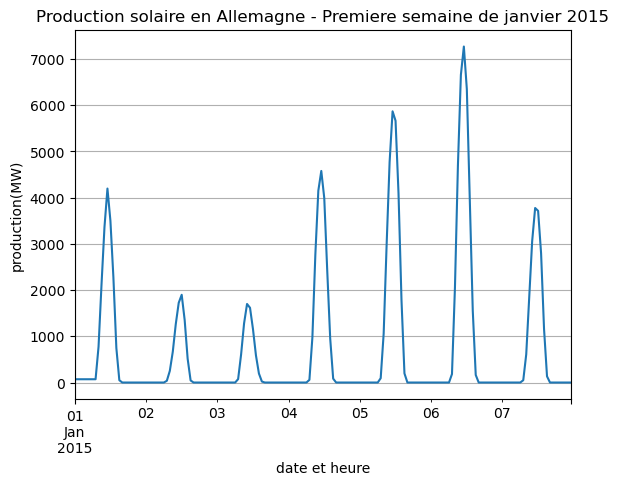

In [736]:
plt.Figure(figsize=(15, 6))
df_Deutschland['DE_solar_generation_actual'].head(168).plot()
plt.title("Production solaire en Allemagne - Premiere semaine de janvier 2015")
plt.xlabel("date et heure")
plt.ylabel("production(MW)")
plt.grid(True)
plt.show()

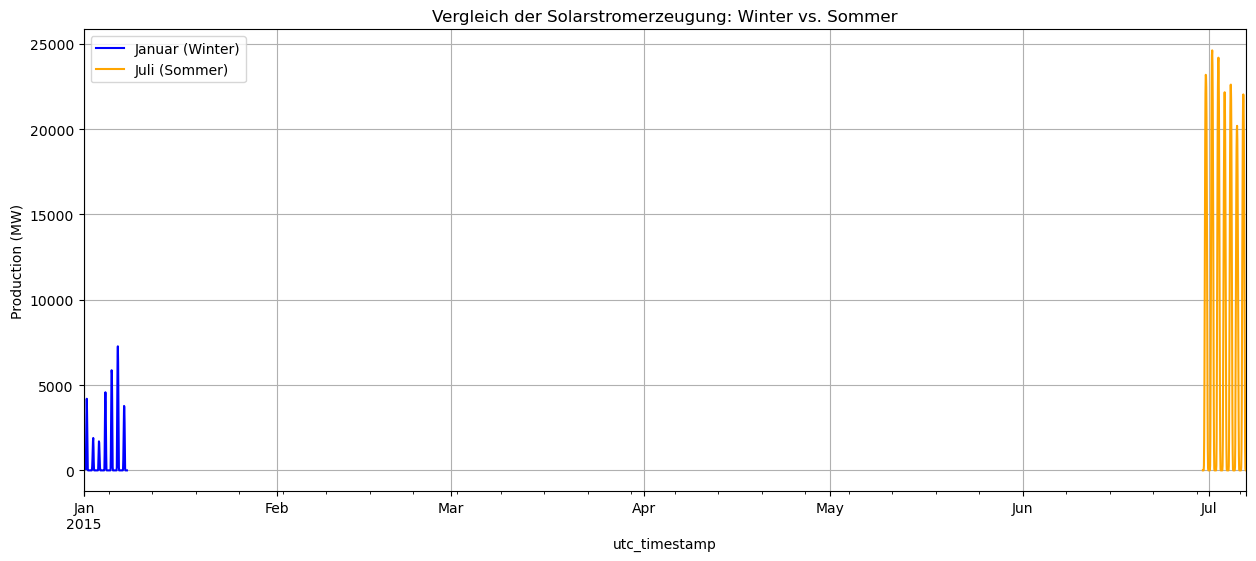

In [737]:
plt.figure(figsize=(15, 6))


df['DE_solar_generation_actual'].iloc[0:168].plot(label='Januar (Winter)', color='blue')

df['DE_solar_generation_actual'].iloc[4320:4488].plot(label='Juli (Sommer)', color='orange')

plt.title("Vergleich der Solarstromerzeugung: Winter vs. Sommer")
plt.ylabel("Production (MW)")
plt.legend() 
plt.grid(True)
plt.show()

In [738]:
print(df_Deutschland['DE_wind_generation_actual'].isnull().sum())
df_Deutschland.head(10)
df_Deutschland.info()

74
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   DE_load_actual_entsoe_transparency    50400 non-null  float64
 1   DE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   DE_solar_capacity                     50400 non-null  float64
 3   DE_solar_generation_actual            50400 non-null  float64
 4   DE_solar_profile                      43696 non-null  float64
 5   DE_wind_capacity                      43799 non-null  float64
 6   DE_wind_generation_actual             50326 non-null  float64
 7   DE_wind_profile                       43725 non-null  float64
 8   DE_wind_offshore_capacity             43799 non-null  float64
 9   DE_wind_offshore_generation_actual    50326 non-null  float64
 10  DE_wind_offshore_profile        

FR : Synchronisation et Intégrité du Mix Énergétique Le nettoyage a été harmonisé sur l'ensemble des sources (Solaire, Éolien Onshore/Offshore) pour atteindre 50 400 lignes cohérentes. L'audit via isnull().sum() a révélé 74 lacunes mineures (0,15%), traitées par interpolation linéaire. Cette méthode garantit une transition fluide des données, évitant les ruptures artificielles dans l'analyse de la complémentarité des énergies renouvelables.

EN : Synchronization and Energy Mix Integrity Data cleaning was standardized across all sources (Solar, Onshore/Offshore Wind) to reach a consistent 50,400 rows. An audit using isnull().sum() identified 74 minor gaps (0.15%), resolved through linear interpolation. This approach ensures smooth data transitions, preventing artificial spikes when analyzing the complementarity of renewable energy sources.

DE : Synchronisierung und Integrität des Energiemixes Die Bereinigung wurde über alle Quellen (Solar, Onshore-/Offshore-Wind) hinweg vereinheitlicht, um konsistente 50.400 Zeilen zu erhalten. Eine Prüfung mittels isnull().sum() ergab 74 geringfügige Lücken (0,15 %), die durch lineare Interpolation behoben wurden. Diese Methode gewährleistet fließende Datenübergänge und verhindert künstliche Sprünge bei der Analyse der Komplementarität erneuerbarer Energien.

In [739]:
col_wind = ['DE_wind_generation_actual', 'DE_wind_offshore_generation_actual', 'DE_wind_onshore_generation_actual']
for col in col_wind : df_Deutschland[col] = df_Deutschland[col].interpolate(method='linear').bfill()
print("L'etat du set apres nettoyage:" ,df_Deutschland[col_wind].isnull().sum())
df_Deutschland.info()

L'etat du set apres nettoyage: DE_wind_generation_actual             0
DE_wind_offshore_generation_actual    0
DE_wind_onshore_generation_actual     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   DE_load_actual_entsoe_transparency    50400 non-null  float64
 1   DE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   DE_solar_capacity                     50400 non-null  float64
 3   DE_solar_generation_actual            50400 non-null  float64
 4   DE_solar_profile                      43696 non-null  float64
 5   DE_wind_capacity                      43799 non-null  float64
 6   DE_wind_generation_actual             50400 non-null  float64
 7   DE_wind_profile                       43725 non-null  float64
 8   DE_wi

FR : Localisation des Lacunes de Capacité L'analyse temporelle des NaN révèle que les données de capacité sont souvent absentes sur des blocs continus (ex: début de l'historique). Contrairement aux pannes de production, ces lacunes reflètent une absence d'enregistrement administratif des parcs installés plutôt qu'un problème technique passager.

EN : Locating Capacity Gaps Time-series analysis of NaN values reveals that capacity data is often missing in continuous blocks (e.g., at the beginning of the record). Unlike production outages, these gaps reflect a lack of administrative records for installed parks rather than a temporary technical glitch.

DE : Lokalisierung von Kapazitätslücken Die Zeitreihenanalyse von NaN-Werten zeigt, dass Kapazitätsdaten oft in kontinuierlichen Blöcken fehlen (z. B. zu Beginn des Datensatzes). Im Gegensatz zu Erzeugungsausfällen spiegeln diese Lücken eher fehlende administrative Aufzeichnungen installierter Parks als ein vorübergehendes technisches Problem wider.

In [740]:
nancapa = df_Deutschland[df_Deutschland['DE_wind_capacity'].isnull()]
print("le nombre de ligne sans capacite", {len(nancapa)})
print("Premier manque",{nancapa.index.min()})
print("dernier manque",{nancapa.index.max()})

le nombre de ligne sans capacite {6601}
Premier manque {Timestamp('2019-12-30 23:00:00+0000', tz='UTC')}
dernier manque {Timestamp('2020-09-30 23:00:00+0000', tz='UTC')}


FR : Définition des Variables de Capacité L'identification explicite des colonnes de capacité dans une liste (cols_capa) permet d'automatiser le traitement par lot. L'application du Forward Fill sur ces variables quasi-statiques assure l'intégrité du dataset jusqu'en septembre 2020, rendant possible le calcul de la performance du parc sur toute la période.

EN : Definition of Capacity Variables Explicitly identifying capacity columns in a list (cols_capa) allows for automated batch processing. Applying Forward Fill to these quasi-static variables ensures dataset integrity through September 2020, enabling the calculation of fleet performance across the entire period.

DE : Definition der Kapazitätsvariablen Die explizite Identifizierung der Kapazitätsspalten in einer Liste (cols_capa) ermöglicht eine automatisierte Stapelverarbeitung. Die Anwendung von Forward Fill auf diese quasi-statischen Variablen stellt die Integrität des Datensatzes bis September 2020 sicher und ermöglicht die Berechnung der Parkleistung über den gesamten Zeitraum.

In [741]:
col_capa = ['DE_solar_capacity', 'DE_wind_capacity', 'DE_wind_offshore_capacity', 'DE_wind_onshore_capacity']
for col in col_capa:
    df_Deutschland[col] = df_Deutschland[col].ffill()
print("verification apres le nettoyage", df_Deutschland[col_capa].isnull().sum())  
df_Deutschland.info()  

verification apres le nettoyage DE_solar_capacity            0
DE_wind_capacity             0
DE_wind_offshore_capacity    0
DE_wind_onshore_capacity     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   DE_load_actual_entsoe_transparency    50400 non-null  float64
 1   DE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   DE_solar_capacity                     50400 non-null  float64
 3   DE_solar_generation_actual            50400 non-null  float64
 4   DE_solar_profile                      43696 non-null  float64
 5   DE_wind_capacity                      50400 non-null  float64
 6   DE_wind_generation_actual             50400 non-null  float64
 7   DE_wind_profile                       43725 non-null  float64
 8   

FR : Recalcul des Indicateurs de Performance (Profiles) Plutôt que d'interpoler des ratios manquants, il est préférable de les recalculer à partir des données sources nettoyées (Generation / Capacity). Cela garantit une cohérence mathématique parfaite sur l'ensemble des 50 400 lignes et élimine les dernières valeurs nulles du dataset.

EN : Recalculating Performance Indicators (Profiles) Instead of interpolating missing ratios, it is better to recalculate them from the cleaned source data (Generation / Capacity). This ensures perfect mathematical consistency across all 50,400 rows and eliminates the remaining null values from the dataset.

DE : Neuberechnung der Performance-Indikatoren (Profiles) Anstatt fehlende Verhältnisse zu interpolieren, ist es besser, sie aus den bereinigten Quelldaten (Generation / Capacity) neu zu berechnen. Dies gewährleistet eine perfekte mathematische Konsistenz über alle 50.400 Zeilen hinweg und beseitigt die verbleibenden Nullwerte aus dem Datensatz

In [742]:
df_Deutschland ['DE_solar_profile'] = df_Deutschland ['DE_solar_generation_actual'] / df_Deutschland['DE_solar_capacity']
df_Deutschland ['DE_wind_profile'] = df_Deutschland ['DE_wind_generation_actual'] / df_Deutschland['DE_wind_capacity']
df_Deutschland ['DE_wind_offshore_profile'] = df_Deutschland ['DE_wind_offshore_generation_actual'] / df_Deutschland['DE_wind_offshore_capacity']
df_Deutschland ['DE_wind_onshore_profile'] = df_Deutschland ['DE_wind_onshore_generation_actual'] / df_Deutschland['DE_wind_onshore_capacity']
df_Deutschland.info()
df_Deutschland.tail()                                                                                                 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   DE_load_actual_entsoe_transparency    50400 non-null  float64
 1   DE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   DE_solar_capacity                     50400 non-null  float64
 3   DE_solar_generation_actual            50400 non-null  float64
 4   DE_solar_profile                      50400 non-null  float64
 5   DE_wind_capacity                      50400 non-null  float64
 6   DE_wind_generation_actual             50400 non-null  float64
 7   DE_wind_profile                       50400 non-null  float64
 8   DE_wind_offshore_capacity             50400 non-null  float64
 9   DE_wind_offshore_generation_actual    50400 non-null  float64
 10  DE_wind_offshore_profile           

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
utc_timestamp,,,,,,,,,,,,,,
2020-09-30 19:00:00+00:00,57559.0,56708.0,50508.0,0.0,0.0,50452.0,10654.0,0.211171,5742.0,4754.0,0.827935,44710.0,5900.0,0.131962
2020-09-30 20:00:00+00:00,54108.0,53270.0,50508.0,0.0,0.0,50452.0,11836.0,0.234599,5742.0,5194.0,0.904563,44710.0,6642.0,0.148557
2020-09-30 21:00:00+00:00,49845.0,49239.0,50508.0,0.0,0.0,50452.0,12168.0,0.241180,5742.0,5339.0,0.929815,44710.0,6829.0,0.152740
2020-09-30 22:00:00+00:00,46886.0,46620.0,50508.0,0.0,0.0,50452.0,12533.0,0.248414,5742.0,5399.0,0.940265,44710.0,7134.0,0.159562
2020-09-30 23:00:00+00:00,45461.0,44986.0,50508.0,0.0,0.0,50452.0,12798.0,0.253667,5742.0,5381.0,0.937130,44710.0,7417.0,0.165891


In [743]:

df_Deutschland['DE_load_forecast_entsoe_transparency'] = df_Deutschland['DE_load_forecast_entsoe_transparency'].interpolate(method='linear')
print(df_Deutschland.isnull().sum())

DE_load_actual_entsoe_transparency      0
DE_load_forecast_entsoe_transparency    0
DE_solar_capacity                       0
DE_solar_generation_actual              0
DE_solar_profile                        0
DE_wind_capacity                        0
DE_wind_generation_actual               0
DE_wind_profile                         0
DE_wind_offshore_capacity               0
DE_wind_offshore_generation_actual      0
DE_wind_offshore_profile                0
DE_wind_onshore_capacity                0
DE_wind_onshore_generation_actual       0
DE_wind_onshore_profile                 0
dtype: int64


FR : Agrégation du Mix Renouvelable (Total RE) La création de la variable Total_RE transforme des données isolées en un indicateur systémique. Elle permet d'analyser la puissance injectée globale et de préparer le calcul du taux de pénétration énergétique, indispensable pour évaluer la réussite de la transition écologique allemande.

EN : Renewable Mix Aggregation (Total RE) Creating the Total_RE variable transforms isolated data into a systemic indicator. It allows for the analysis of total power injection and sets the stage for calculating the energy penetration rate, essential for assessing the success of the German energy transition.

DE : Aggregation des Erneuerbaren-Mixes (Total RE) Die Erstellung der Variable Total_RE verwandelt isolierte Daten in einen systemischen Indikator. Sie ermöglicht die Analyse der gesamten eingespeisten Leistung und bereitet die Berechnung des Energiedurchdringungsgrads vor, der für die Bewertung des Erfolgs der deutschen Energiewende unerlässlich ist.

In [744]:
df_Deutschland['Total_RE_generation'] = (df_Deutschland['DE_solar_generation_actual']+ df_Deutschland['DE_wind_onshore_generation_actual']+ df_Deutschland['DE_wind_offshore_generation_actual'])
df_Deutschland['Total_RE_capacity'] = (df_Deutschland['DE_solar_capacity'] + df_Deutschland['DE_wind_capacity'])
print(df_Deutschland[['Total_RE_generation', 'Total_RE_capacity', 'DE_load_actual_entsoe_transparency']].head())

                           Total_RE_generation  Total_RE_capacity  \
utc_timestamp                                                       
2015-01-01 00:00:00+00:00               8924.0            65161.0   
2015-01-01 01:00:00+00:00               9125.0            65161.0   
2015-01-01 02:00:00+00:00               9141.0            65161.0   
2015-01-01 03:00:00+00:00               9234.0            65161.0   
2015-01-01 04:00:00+00:00               9303.0            65161.0   

                           DE_load_actual_entsoe_transparency  
utc_timestamp                                                  
2015-01-01 00:00:00+00:00                             41151.0  
2015-01-01 01:00:00+00:00                             40135.0  
2015-01-01 02:00:00+00:00                             39106.0  
2015-01-01 03:00:00+00:00                             38765.0  
2015-01-01 04:00:00+00:00                             38941.0  


In [745]:
df_Deutschland['Total_RE_generation'] = (df_Deutschland['DE_solar_generation_actual']+ df_Deutschland['DE_wind_onshore_generation_actual']+ df_Deutschland['DE_wind_offshore_generation_actual'])
df_Deutschland['RE_penetration_rate'] = (df_Deutschland['Total_RE_generation'] / df_Deutschland ['DE_load_actual_entsoe_transparency'])*100
print(f"Moyenne de couverture: {df_Deutschland['RE_penetration_rate'].mean(): .2f}%")
print(f"Minimum de couverture: {df_Deutschland['RE_penetration_rate'].min(): .2f}%")
print(f"Record de couverture: {df_Deutschland['RE_penetration_rate'].max(): .2f}%")

Moyenne de couverture:  28.95%
Minimum de couverture:  0.50%
Record de couverture:  98.71%


In [746]:
gap = np.abs(df_Deutschland['DE_load_actual_entsoe_transparency'] - df_Deutschland['DE_load_forecast_entsoe_transparency'])
df_Deutschland['MAPE_load'] = (gap / df_Deutschland['DE_load_actual_entsoe_transparency'])*100
print(f"l'erreur moyenne de prevision est de :{ df_Deutschland['MAPE_load'].mean():.2f}%")

l'erreur moyenne de prevision est de :3.06%


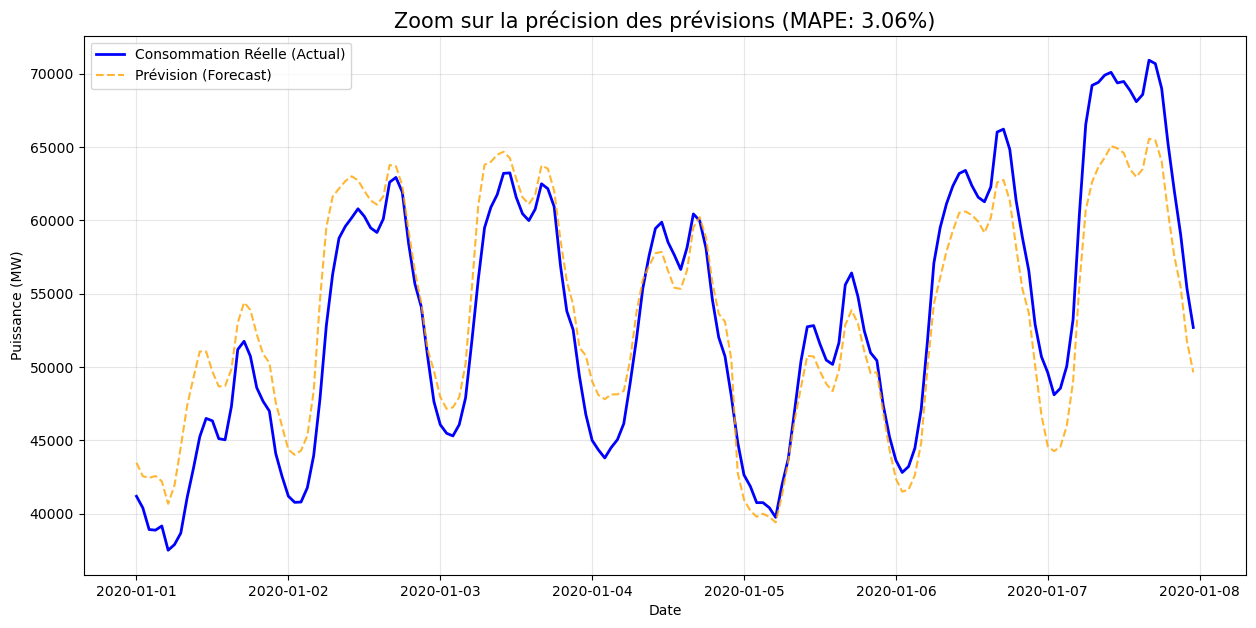

In [747]:
import matplotlib.pyplot as plt

# 1. Sélection d'une semaine (du 1er au 7 janvier 2020)
start_date = '2020-01-01'
end_date = '2020-01-07'
semaine_test = df_Deutschland.loc[start_date:end_date]

# 2. Création de la figure
plt.figure(figsize=(15, 7))

# 3. Tracé des courbes
plt.plot(semaine_test.index, semaine_test['DE_load_actual_entsoe_transparency'], 
         label='Consommation Réelle (Actual)', color='blue', linewidth=2)
plt.plot(semaine_test.index, semaine_test['DE_load_forecast_entsoe_transparency'], 
         label='Prévision (Forecast)', color='orange', linestyle='--', alpha=0.8)

# 4. Habillage du graphique
plt.title(f"Zoom sur la précision des prévisions (MAPE: {df_Deutschland['MAPE_load'].mean():.2f}%)", fontsize=15)
plt.ylabel("Puissance (MW)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()